<a href="https://colab.research.google.com/github/ezequielcabeja/Geological-Logging-Dataset/blob/main/Geological_Logging_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Geological Logging Dataset**

1. **Data analysis with Pandas** | Análise dos dados com Pandas

In [69]:
import pandas as pd
import numpy as np

In [70]:
df=pd.read_csv("/force2020_data_unsupervised_learning.csv")

* **RHOB (Bulk Density):** This is the density of the rock including the pore spaces. It helps in estimating the volume of hydrocarbons in the reservoir.

* **GR (Gamma Ray):** This measures the natural radioactivity of the rocks. It is used to differentiate between shales and non-shales (such as sandstone and limestone).

* **DEPTH_MD (Measured Depth):** This is the depth of the well measured along the wellbore, typically from the surface down to the depth of interest.

* **NPHI (Neutron Porosity):** This measures the porosity of the rock by assessing the response of hydrogen atoms to neutron radiation. It is particularly useful for identifying the amount of water and hydrocarbons in the pores.

* **PEF (Photoelectric Factor):** This is a measure that helps to differentiate between mineral types in the rock. It indicates the response of a rock to gamma radiation and can assist in estimating lithology and fluid types.

* **DTC (Compressional Wave Velocity):** This measures the velocity of compressional waves traveling through the rock. It's important for evaluating rock properties and can help in determining the presence of hydrocarbons.

These measurements are crucial for interpreting subsurface geology and assessing reservoir potential in oil and gas exploration.

*This dataset is used to clustering*

In [71]:
df.head()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,1.884186,80.200851,494.528,NaN,20.915468,161.131180
1,1.889794,79.262886,494.680,NaN,19.383013,160.603470
2,1.896523,74.821999,494.832,NaN,22.591518,160.173615
3,1.891913,72.878922,494.984,NaN,32.191910,160.149429
4,1.880034,71.729141,495.136,NaN,38.495632,160.128342


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18270 entries, 0 to 18269
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RHOB      18270 non-null  float64
 1   GR        18270 non-null  float64
 2   DEPTH_MD  18270 non-null  float64
 3   NPHI      14032 non-null  float64
 4   PEF       16440 non-null  float64
 5   DTC       18189 non-null  float64
dtypes: float64(6)
memory usage: 856.5 KB


In [73]:
df.describe()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
count,18270.000000,18270.000000,18270.000000,14032.000000,16440.000000,18189.000000
mean,2.110451,63.847477,1883.228478,0.404547,3.463851,125.106178
std,0.297725,28.636331,801.941195,0.133532,2.561239,30.618337
min,1.404576,6.191506,494.528000,0.024330,1.010027,55.726753
25%,1.963399,43.866690,1188.750000,0.315346,2.320836,90.883087
50%,2.055079,66.777851,1882.972000,0.448527,2.790249,141.300461
75%,2.381963,81.542681,2577.802000,0.506343,4.267342,148.048355
max,2.927888,499.022583,3272.024000,0.800262,66.030319,175.953140


In [74]:
df.shape

(18270, 6)

In [75]:
linhas, colunas = df.shape[0], df.shape[1]
print("Linhas:", linhas)
print("Colunas:", colunas)

Linhas: 18270
Colunas: 6


In [76]:
df.columns

Index(['RHOB', 'GR', 'DEPTH_MD', 'NPHI', 'PEF', 'DTC'], dtype='object')

In [77]:
df_p = df.rename(columns={
    'RHOB': 'Densidade_Aparente_RHOB',
    'GR': 'Raios_Gama_GR',
    'DEPTH_MD': 'Profundidade_Medida_DEPTH_MD',
    'NPHI': 'Porosidade_Neutrao_NPHI',
    'PEF': 'Fator_Fotoeletrico_PEF',
    'DTC': 'Velocidade_Onda_Compressional_DTC'
})

In [78]:
df_p.columns

Index(['Densidade_Aparente_RHOB', 'Raios_Gama_GR',
       'Profundidade_Medida_DEPTH_MD', 'Porosidade_Neutrao_NPHI',
       'Fator_Fotoeletrico_PEF', 'Velocidade_Onda_Compressional_DTC'],
      dtype='object')

In [79]:
df.columns

Index(['RHOB', 'GR', 'DEPTH_MD', 'NPHI', 'PEF', 'DTC'], dtype='object')

In [80]:
df['RHOB'].value_counts()

,count
RHOB,
1.418000,7
1.413100,7
2.011700,7
1.417000,6
1.412100,6
...,...
2.163614,1
2.131393,1
2.089724,1


In [81]:
df['NPHI'].value_counts()

,count
NPHI,
0.295400,3
0.420106,2
0.525167,2
0.345200,2
0.508028,2
...,...
0.513292,1
0.513445,1
0.543151,1


In [82]:
df.describe(include="all")

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
count,18270.000000,18270.000000,18270.000000,14032.000000,16440.000000,18189.000000
mean,2.110451,63.847477,1883.228478,0.404547,3.463851,125.106178
std,0.297725,28.636331,801.941195,0.133532,2.561239,30.618337
min,1.404576,6.191506,494.528000,0.024330,1.010027,55.726753
25%,1.963399,43.866690,1188.750000,0.315346,2.320836,90.883087
50%,2.055079,66.777851,1882.972000,0.448527,2.790249,141.300461
75%,2.381963,81.542681,2577.802000,0.506343,4.267342,148.048355
max,2.927888,499.022583,3272.024000,0.800262,66.030319,175.953140


# 2. **Data Preparation and Cleaning** | Preparação e Limpeza dos Dados

In [83]:
df.isnull()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,False,False,False,True,False,False
1,False,False,False,True,False,False
2,False,False,False,True,False,False
3,False,False,False,True,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
18265,False,False,False,False,True,True
18266,False,False,False,False,True,True
18267,False,False,False,False,True,True
18268,False,False,False,False,True,True


In [84]:
df.isnull().sum()

,0
RHOB,0
GR,0
DEPTH_MD,0
NPHI,4238
PEF,1830
DTC,81


In [85]:
#Filling the missing values in DTC: Linar Interpolation
df_clean=df.copy()
df_clean["DTC"]=df["DTC"].interpolate(method="linear")

In [86]:
df_clean.isnull().sum()

,0
RHOB,0
GR,0
DEPTH_MD,0
NPHI,4238
PEF,1830
DTC,0


In [87]:
#Filling the missing values in PEF: KNNImputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

#We apply the imputer only to the selected columns
# (We use df_clean to fit and transform only those columns)
imputed_values = imputer.fit_transform(df_clean[['PEF', 'NPHI']])

In [88]:
df_clean[['PEF', 'NPHI']] = imputed_values

In [89]:
df_clean.isnull()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
18265,False,False,False,False,False,False
18266,False,False,False,False,False,False
18267,False,False,False,False,False,False
18268,False,False,False,False,False,False


In [90]:
df_clean.isnull().sum()

,0
RHOB,0
GR,0
DEPTH_MD,0
NPHI,0
PEF,0
DTC,0


In [91]:
df_clean.head()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,1.884186,80.200851,494.528,0.465726,20.915468,161.131180
1,1.889794,79.262886,494.680,0.465726,19.383013,160.603470
2,1.896523,74.821999,494.832,0.465726,22.591518,160.173615
3,1.891913,72.878922,494.984,0.465726,32.191910,160.149429
4,1.880034,71.729141,495.136,0.465726,38.495632,160.128342


In [92]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18270 entries, 0 to 18269
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RHOB      18270 non-null  float64
 1   GR        18270 non-null  float64
 2   DEPTH_MD  18270 non-null  float64
 3   NPHI      18270 non-null  float64
 4   PEF       18270 non-null  float64
 5   DTC       18270 non-null  float64
dtypes: float64(6)
memory usage: 856.5 KB


In [93]:
df_clean.describe()

,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
count,18270.000000,18270.000000,18270.000000,18270.000000,18270.000000,18270.000000
mean,2.110451,63.847477,1883.228478,0.434171,3.590795,124.909405
std,0.297725,28.636331,801.941195,0.130453,2.475631,30.692363
min,1.404576,6.191506,494.528000,0.024330,1.010027,55.726753
25%,1.963399,43.866690,1188.750000,0.344110,2.355565,90.656336
50%,2.055079,66.777851,1882.972000,0.478981,2.979455,141.197800
75%,2.381963,81.542681,2577.802000,0.525575,4.505243,148.012402
max,2.927888,499.022583,3272.024000,0.800262,66.030319,175.953140


# **Data Visualization** | Visualização de Dados

<Axes: title={'center': 'Distribuition RHOB (Bulk Density)'}, ylabel='Frequency'>

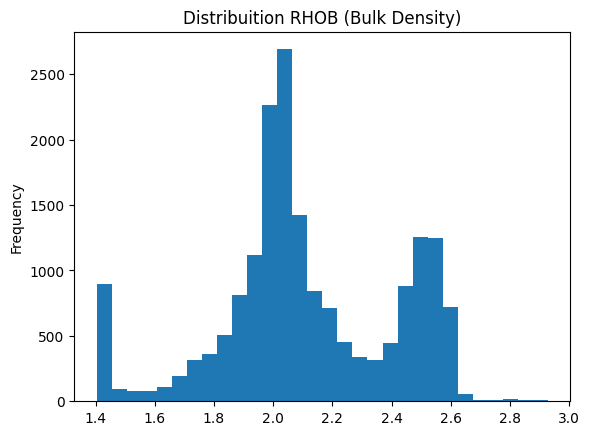

In [94]:
df_clean['RHOB'].plot(kind="hist", bins=30, title="Distribuition RHOB (Bulk Density)")

In [95]:
#Using Seaborn Library
import seaborn as sns

<Axes: xlabel='RHOB', ylabel='Count'>

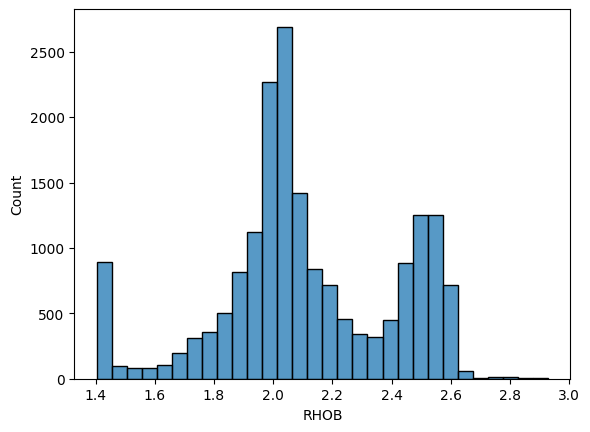

In [96]:
sns.histplot(data=df_clean, x="RHOB", bins=30, kde=False)

In [97]:
#Using Matplotlib Library
import matplotlib.pyplot as plt

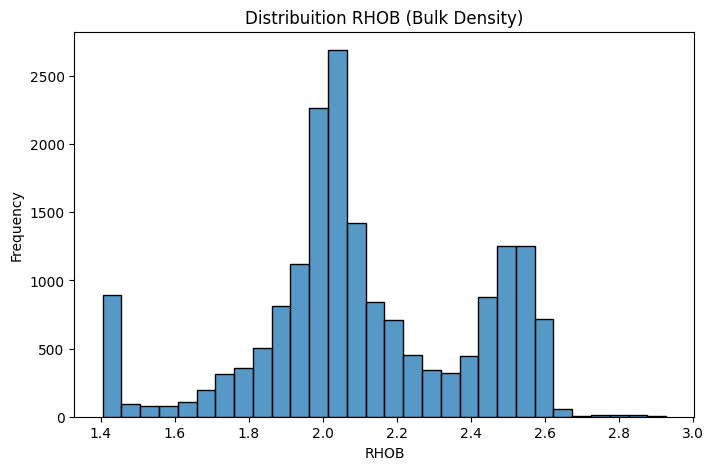

In [98]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="RHOB", bins=30, kde=False)
plt.title("Distribuition RHOB (Bulk Density)")
plt.xlabel("RHOB")
plt.ylabel("Frequency")

plt.show()


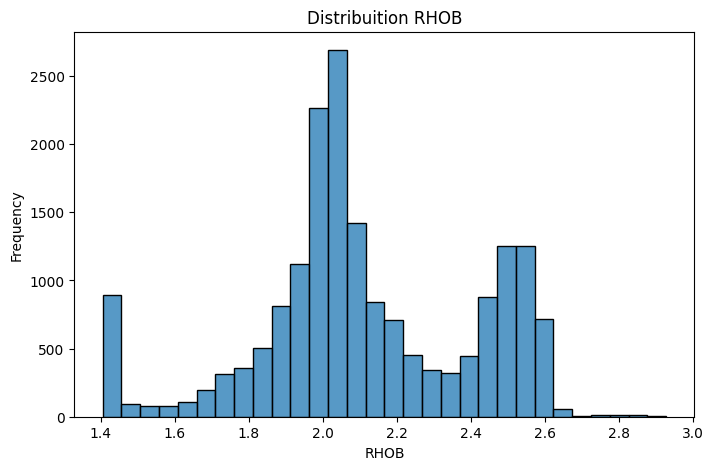

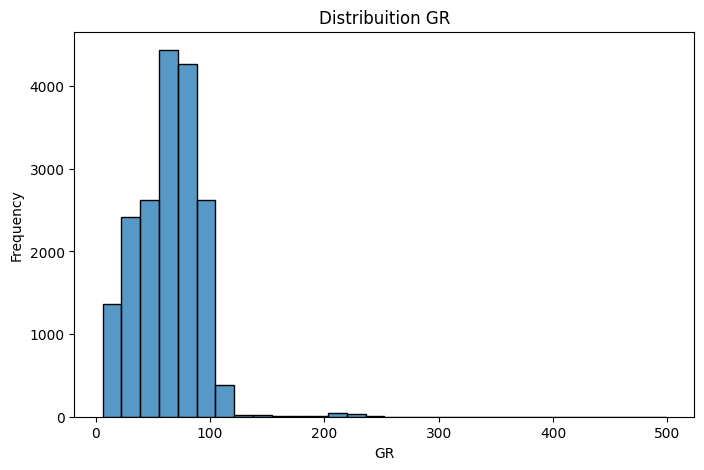

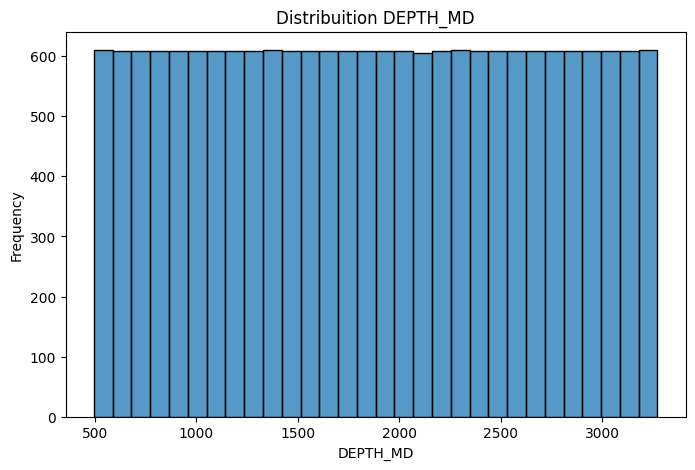

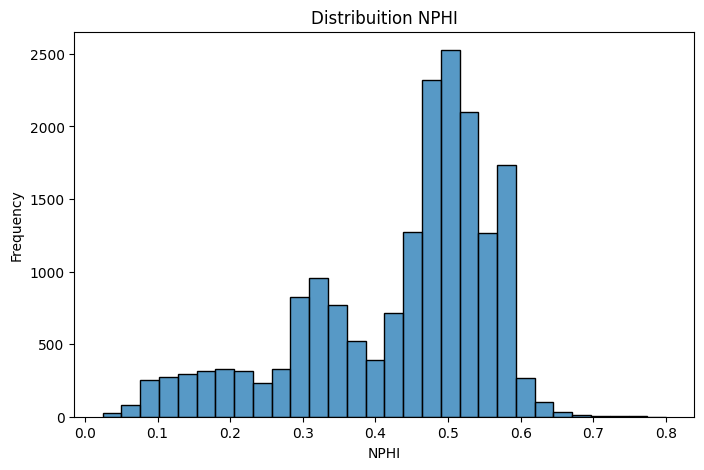

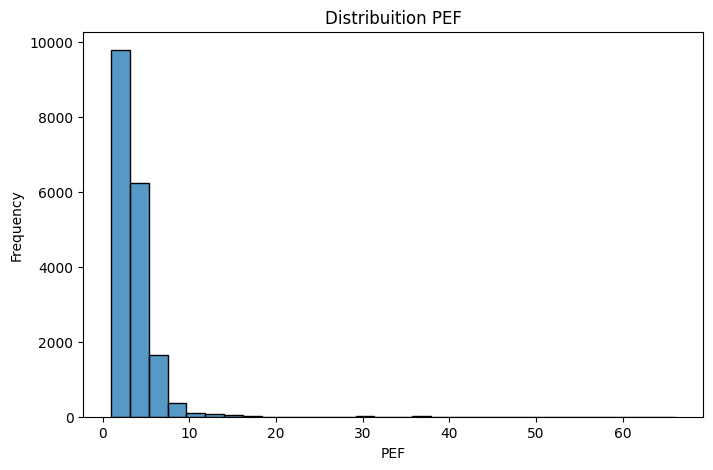

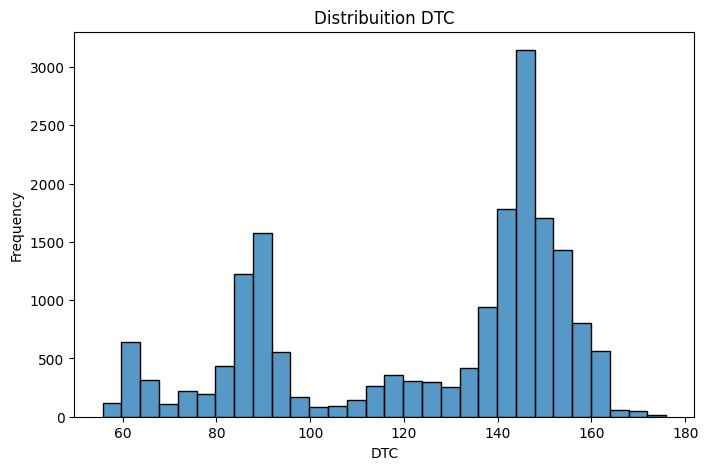

In [99]:
for i in df_clean.columns:
  plt.figure(figsize=(8, 5))

  sns.histplot(df_clean[i], bins=30, kde=False)
  plt.title(f"Distribuition {i}")
  plt.xlabel(i)
  plt.ylabel("Frequency")

  plt.show()

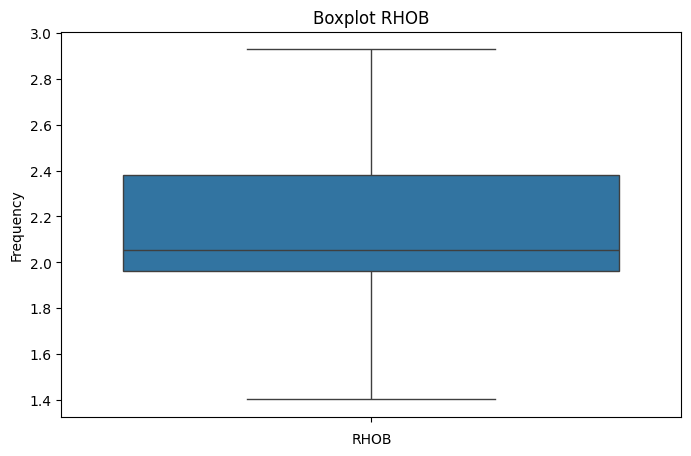

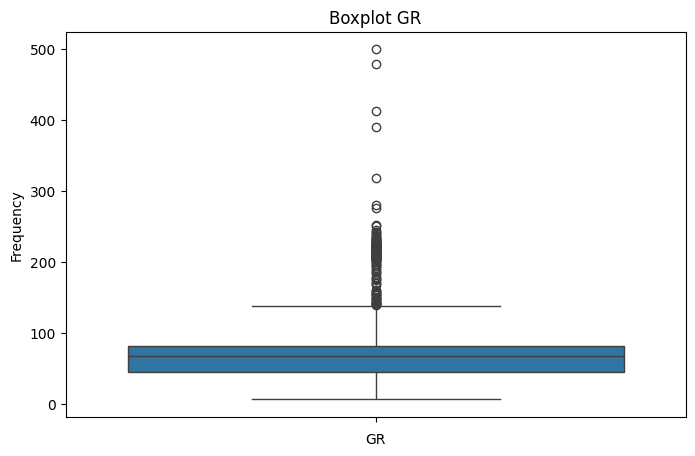

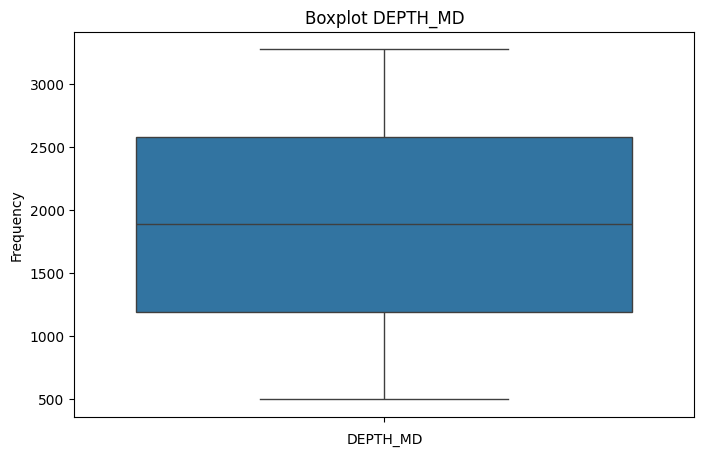

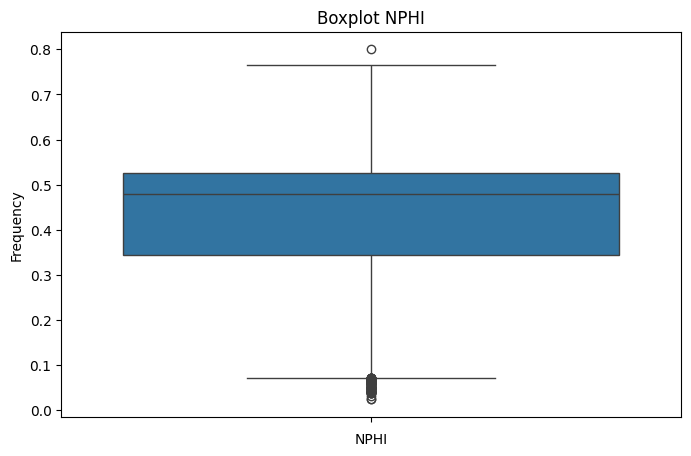

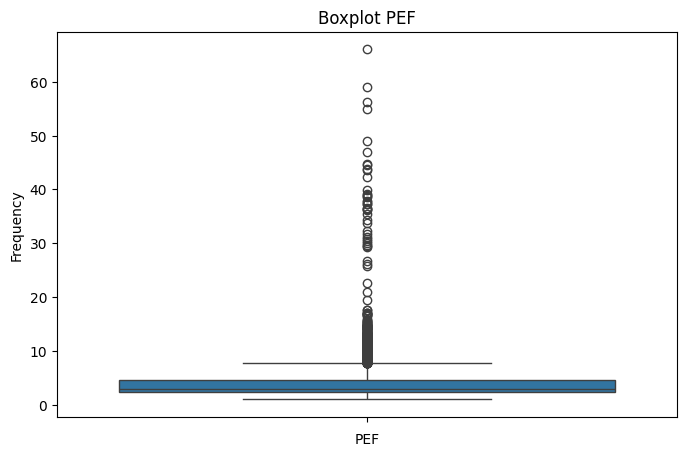

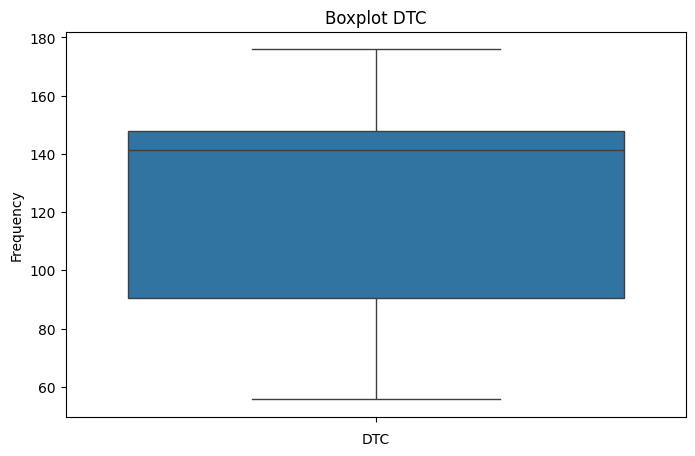

In [100]:
#Using Boxplot
for i in df_clean.columns:
  plt.figure(figsize=(8, 5))

  sns.boxplot(df_clean[i])
  plt.title(f"Boxplot {i}")
  plt.xlabel(i)
  plt.ylabel("Frequency")

  plt.show()

In [101]:
#Using Plotly Library to make a interative plot
import plotly.express as px

In [102]:
for i in df_clean.columns:
  fig= px.histogram(
      df_clean,
      x=i,
      nbins=30,
      title=f"Distribuition {i}",
      labels={i:i, "count":"Frequency"}
      #template="plotly_white"
  )
  fig.show()